In [4]:
import json
import os
from pathlib import Path

import pandas as pd

match_id = 2017461  # Melbourne Victory vs Auckland FC, 17 May 2025
project_root = Path.cwd().resolve().parent
match_dir = project_root / "opendata" / "data" / "matches" / str(match_id)
tracking_path = match_dir / f"{match_id}_tracking_extrapolated.jsonl"
match_json_path = match_dir / f"{match_id}_match.json"

assert tracking_path.is_file(), f"Tracking file not found: {tracking_path}"
assert match_json_path.is_file(), f"Match file not found: {match_json_path}"

with tracking_path.open(encoding="utf-8") as f:
    records = [json.loads(line) for line in f]

# JSON decoding preserves timestamps as elapsed-time strings.
tracking_raw = pd.DataFrame(records)
tracking = tracking_raw.copy()

with match_json_path.open(encoding="utf-8") as f:
    match_info = json.load(f)

print(f"Working directory: {Path.cwd()}")
print(f"Match directory: {match_dir}")
print(f"Tracking shape: {tracking_raw.shape}")

Working directory: c:\Users\HP\tactIQ\notebooks
Match directory: C:\Users\HP\tactIQ\opendata\data\matches\2017461
Tracking shape: (71451, 7)


In [5]:
for root, dirs, files in os.walk("."):
    for file in files:
        print(os.path.join(root, file))

.\01_explore_skillcorner.ipynb


In [6]:
import pandas as pd
import json
from pathlib import Path

records = []

with open(tracking_path, "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))

tracking_raw = pd.DataFrame(records)

print(tracking_raw.shape)
print(tracking_raw.columns.tolist())

display(tracking_raw.head())

(71451, 7)
['frame', 'timestamp', 'period', 'ball_data', 'possession', 'image_corners_projection', 'player_data']


,frame,timestamp,period,ball_data,possession,image_corners_projection,player_data
0,0,NaN,NaN,"{'x': None, 'y': None, 'z': None, 'is_detected...","{'player_id': None, 'group': None}","{'x_top_left': None, 'y_top_left': None, 'x_bo...",[]
1,1,NaN,NaN,"{'x': None, 'y': None, 'z': None, 'is_detected...","{'player_id': None, 'group': None}","{'x_top_left': None, 'y_top_left': None, 'x_bo...",[]
2,2,NaN,NaN,"{'x': None, 'y': None, 'z': None, 'is_detected...","{'player_id': None, 'group': None}","{'x_top_left': None, 'y_top_left': None, 'x_bo...",[]
3,3,NaN,NaN,"{'x': None, 'y': None, 'z': None, 'is_detected...","{'player_id': None, 'group': None}","{'x_top_left': None, 'y_top_left': None, 'x_bo...",[]
4,4,NaN,NaN,"{'x': None, 'y': None, 'z': None, 'is_detected...","{'player_id': None, 'group': None}","{'x_top_left': None, 'y_top_left': None, 'x_bo...",[]


In [7]:
# Find the first frame that actually contains player data
first_player_frame = tracking[tracking["player_data"].apply(len) > 0].iloc[0]

print("Frame:", first_player_frame["frame"])
print("Timestamp:", first_player_frame["timestamp"])
print("Period:", first_player_frame["period"])

print("\nPlayer data:")
print(first_player_frame["player_data"])

Frame: 2510
Timestamp: 00:00:00.00
Period: 1.0

Player data:
[{'x': -38.16, 'y': 1.51, 'player_id': 51678, 'is_detected': False}, {'x': -20.78, 'y': 3.31, 'player_id': 51013, 'is_detected': True}, {'x': -20.93, 'y': 14.81, 'player_id': 51685, 'is_detected': True}, {'x': -21.03, 'y': -8.49, 'player_id': 800322, 'is_detected': True}, {'x': -8.6, 'y': 23.72, 'player_id': 811820, 'is_detected': True}, {'x': -6.26, 'y': 7.29, 'player_id': 159688, 'is_detected': True}, {'x': -6.21, 'y': -6.49, 'player_id': 157294, 'is_detected': True}, {'x': 1.14, 'y': 16.43, 'player_id': 11117, 'is_detected': False}, {'x': 0.68, 'y': 0.69, 'player_id': 11885, 'is_detected': True}, {'x': 4.59, 'y': 31.88, 'player_id': 50955, 'is_detected': True}, {'x': -0.31, 'y': 13.92, 'player_id': 29075, 'is_detected': True}, {'x': 40.27, 'y': 1.86, 'player_id': 285188, 'is_detected': False}, {'x': 19.72, 'y': 9.69, 'player_id': 51667, 'is_detected': True}, {'x': 18.83, 'y': 1.68, 'player_id': 33697, 'is_detected': True},

In [8]:
print("\nBall data:")
print(first_player_frame["ball_data"])

print("\nPossession:")
print(first_player_frame["possession"])


Ball data:
{'x': -0.46, 'y': -0.12, 'z': 0.14, 'is_detected': True}

Possession:
{'player_id': None, 'group': None}


In [9]:
# Look at the match metadata/files to find player information
import os
from pathlib import Path

match_dir = project_root / "opendata" / "data" / "matches" / str(match_id)

print("Files in match directory:\n")

for path in match_dir.iterdir():
    print(path.name)

Files in match directory:

2017461_dynamic_events.csv
2017461_match.json
2017461_phases_of_play.csv
2017461_tracking_extrapolated.jsonl


In [10]:
print("Number of unique player IDs:")

player_ids = set()

for players in tracking["player_data"]:
    for player in players:
        player_ids.add(player["player_id"])

print(len(player_ids))
print(sorted(player_ids))

Number of unique player IDs:
32
[4322, 11117, 11885, 14736, 23418, 29075, 31147, 33697, 38673, 43829, 50951, 50955, 50977, 50979, 51013, 51667, 51678, 51685, 51713, 51714, 133498, 133501, 157294, 159688, 285188, 582974, 624628, 745320, 795521, 800322, 811820, 965685]


In [11]:
import json

match_json_path = match_dir / f"{match_id}_match.json"

with open(match_json_path, "r", encoding="utf-8") as f:
    match_info = json.load(f)

print(json.dumps(match_info, indent=2)[:15000])

{
  "id": 2017461,
  "home_team_score": 0,
  "away_team_score": 1,
  "date_time": "2025-05-17T09:35:00Z",
  "stadium": {
    "id": 1480,
    "name": "Melbourne Rectangular Stadium",
    "city": "Melbourne",
    "capacity": 30050
  },
  "home_team": {
    "id": 868,
    "name": "Melbourne Victory Football Club",
    "short_name": "Melbourne V FC",
    "acronym": "MEL"
  },
  "home_team_kit": {
    "id": 17096,
    "team_id": 868,
    "season": {
      "id": 95,
      "start_year": 2024,
      "end_year": 2025,
      "name": "2024/2025"
    },
    "name": "Home",
    "jersey_color": "#001536",
    "number_color": "#FFFFFF"
  },
  "away_team": {
    "id": 4177,
    "name": "Auckland FC",
    "short_name": "Auckland FC",
    "acronym": "AUC"
  },
  "away_team_kit": {
    "id": 14075,
    "team_id": 4177,
    "season": {
      "id": 95,
      "start_year": 2024,
      "end_year": 2025,
      "name": "2024/2025"
    },
    "name": "away",
    "jersey_color": "#ffffff",
    "number_color": "#

In [12]:
print(match_info.keys())

dict_keys(['id', 'home_team_score', 'away_team_score', 'date_time', 'stadium', 'home_team', 'home_team_kit', 'away_team', 'away_team_kit', 'home_team_coach', 'away_team_coach', 'home_team_playing_time', 'away_team_playing_time', 'competition_edition', 'match_periods', 'competition_round', 'referees', 'players', 'status', 'home_team_side', 'ball', 'pitch_length', 'pitch_width'])


In [13]:
# Find frame 2510 by its frame value; it is not necessarily file line 2511.
raw_frame = next(record for record in records if record["frame"] == 2510)

print(raw_frame.keys())
print("frame:", raw_frame["frame"])
print("timestamp:", raw_frame["timestamp"])
print("period:", raw_frame["period"])

dict_keys(['frame', 'timestamp', 'period', 'ball_data', 'possession', 'image_corners_projection', 'player_data'])
frame: 2510
timestamp: 00:00:00.00
period: 1


In [14]:
# Inspect the player records in match.json

print(f"Number of players in match.json: {len(match_info['players'])}")

print("\nFirst player:")
print(json.dumps(match_info["players"][0], indent=2))

Number of players in match.json: 36

First player:
{
  "player_role": {
    "id": 13,
    "position_group": "Wide Attacker",
    "name": "Right Winger",
    "acronym": "RW"
  },
  "start_time": "01:23:12",
  "end_time": null,
  "number": 23,
  "yellow_card": 0,
  "red_card": 0,
  "injured": false,
  "goal": 0,
  "own_goal": 0,
  "playing_time": {
    "total": {
      "minutes_tip": 4.3,
      "minutes_otip": 2.41,
      "start_frame": 62590,
      "end_frame": 70419,
      "minutes_played": 13.05,
      "minutes_played_regular_time": 13.05
    },
    "by_period": [
      {
        "name": "period_2",
        "minutes_tip": 4.3,
        "minutes_otip": 2.41,
        "start_frame": 62590,
        "end_frame": 70419,
        "minutes_played": 13.05
      }
    ]
  },
  "team_player_id": 1564070,
  "team_id": 868,
  "id": 795521,
  "first_name": "Alexander",
  "last_name": "Badolato",
  "short_name": "A. Badolato",
  "birthday": "2005-02-23",
  "trackable_object": 797084,
  "gender": "male

In [15]:
# Inspect the team information

print("HOME:")
print(json.dumps(match_info["home_team"], indent=2))

print("\nAWAY:")
print(json.dumps(match_info["away_team"], indent=2))

HOME:
{
  "id": 868,
  "name": "Melbourne Victory Football Club",
  "short_name": "Melbourne V FC",
  "acronym": "MEL"
}

AWAY:
{
  "id": 4177,
  "name": "Auckland FC",
  "short_name": "Auckland FC",
  "acronym": "AUC"
}


In [16]:
# The file begins with pre-match frames whose timestamps are null.
# Inspect the first genuine match-clock values from the raw JSONL records.
tracking["timestamp_raw"] = tracking_raw["timestamp"]
print(tracking.loc[tracking["timestamp_raw"].notna(), "timestamp_raw"].head(20))

2510    00:00:00.00
2511    00:00:00.10
2512    00:00:00.20
2513    00:00:00.30
2514    00:00:00.40
2515    00:00:00.50
2516    00:00:00.60
2517    00:00:00.70
2518    00:00:00.80
2519    00:00:00.90
2520    00:00:01.00
2521    00:00:01.10
2522    00:00:01.20
2523    00:00:01.30
2524    00:00:01.40
2525    00:00:01.50
2526    00:00:01.60
2527    00:00:01.70
2528    00:00:01.80
2529    00:00:01.90
Name: timestamp_raw, dtype: str


In [17]:
print("Raw match-clock timestamps:")
print(tracking_raw.loc[tracking_raw["timestamp"].notna(), "timestamp"].head(20).tolist())

print("\nPitch length:", match_info["pitch_length"])
print("Pitch width:", match_info["pitch_width"])
print("Home team:", match_info["home_team"]["name"])
print("Away team:", match_info["away_team"]["name"])
print("Home side:", match_info["home_team_side"])

Raw match-clock timestamps:
['00:00:00.00', '00:00:00.10', '00:00:00.20', '00:00:00.30', '00:00:00.40', '00:00:00.50', '00:00:00.60', '00:00:00.70', '00:00:00.80', '00:00:00.90', '00:00:01.00', '00:00:01.10', '00:00:01.20', '00:00:01.30', '00:00:01.40', '00:00:01.50', '00:00:01.60', '00:00:01.70', '00:00:01.80', '00:00:01.90']

Pitch length: 105
Pitch width: 68
Home team: Melbourne Victory Football Club
Away team: Auckland FC
Home side: ['left_to_right', 'right_to_left']


In [18]:
# Build the metadata lookup used to identify tracked players.
player_records = []

for player in match_info["players"]:
    player_records.append({
        "trackable_object": player["trackable_object"],
        "player_name": f"{player.get('first_name', '').strip()} {player.get('last_name', '').strip()}".strip(),
        "team_id": player.get("team_id"),
        "player_number": player.get("number"),
        "position": player.get("player_role", {}).get("name"),
        "position_group": player.get("player_role", {}).get("position_group"),
        "start_time": player.get("start_time"),
        "end_time": player.get("end_time"),
    })

players_df = pd.DataFrame(player_records)

print(f"Players: {len(players_df)}")
display(players_df.head())

Players: 36


,trackable_object,player_name,team_id,player_number,position,position_group,start_time,end_time
0,797084,Alexander Badolato,868,23,Right Winger,Wide Attacker,01:23:12,NaN
1,967248,Liam Gillion,4177,14,Left Winger,Wide Attacker,01:02:21,NaN
2,32245,Tommy Smith,4177,5,Center Back,Central Defender,01:14:54,NaN
3,52081,Nishan Velupillay,868,17,Left Winger,Wide Attacker,00:00:00,01:23:12
4,24342,Luis Felipe Gallegos Leiva,4177,28,Left Midfield,Midfield,00:00:00,01:19:39


In [19]:
print(players_df.columns.tolist())
print(players_df[[
    "trackable_object", "player_name", "team_id", "player_number", "position", "position_group"
]].to_string(index=False))

tracking_player_ids = {
    player["player_id"]
    for players in tracking_raw["player_data"]
    for player in players
}
metadata_player_ids = set(players_df["trackable_object"].dropna())

print(f"\nTracking IDs: {len(tracking_player_ids)}")
print(f"Metadata IDs: {len(metadata_player_ids)}")
print("\nTracking IDs not found in metadata:")
print(sorted(tracking_player_ids - metadata_player_ids))
print("\nMetadata IDs not found in tracking:")
print(sorted(metadata_player_ids - tracking_player_ids))

['trackable_object', 'player_name', 'team_id', 'player_number', 'position', 'position_group', 'start_time', 'end_time']
 trackable_object                   player_name  team_id  player_number                 position   position_group
           797084            Alexander Badolato      868             23             Right Winger    Wide Attacker
           967248                  Liam Gillion     4177             14              Left Winger    Wide Attacker
            32245                   Tommy Smith     4177              5              Center Back Central Defender
            52081             Nishan Velupillay      868             17              Left Winger    Wide Attacker
            24342    Luis Felipe Gallegos Leiva     4177             28            Left Midfield         Midfield
            52077                  Jake Brimmer     4177             22            Left Midfield         Midfield
           135053              Francis De Vries     4177             15           

In [20]:
def timestamp_to_seconds(timestamp):
    hours, minutes, seconds = timestamp.split(":")
    return int(hours) * 3600 + int(minutes) * 60 + float(seconds)

# Pre-match frames have no timestamp; leave their elapsed time missing.
# Keep tracking_raw unchanged by assigning the derived column to a new dataframe.
tracking_with_time = tracking_raw.assign(
    elapsed_seconds=tracking_raw["timestamp"].apply(
        lambda timestamp: timestamp_to_seconds(timestamp) if pd.notna(timestamp) else pd.NA
    )
)

display(
    tracking_with_time.loc[tracking_with_time["timestamp"].notna(),
        ["frame", "timestamp", "elapsed_seconds", "period"]
    ].head(20)
)

,frame,timestamp,elapsed_seconds,period
2510,2510,00:00:00.00,0.0,1.0
2511,2511,00:00:00.10,0.1,1.0
2512,2512,00:00:00.20,0.2,1.0
2513,2513,00:00:00.30,0.3,1.0
2514,2514,00:00:00.40,0.4,1.0
2515,2515,00:00:00.50,0.5,1.0
2516,2516,00:00:00.60,0.6,1.0
2517,2517,00:00:00.70,0.7,1.0
2518,2518,00:00:00.80,0.8,1.0
2519,2519,00:00:00.90,0.9,1.0


In [21]:
# Import the reusable transformation from the project source package.
import sys

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data import flatten_player_tracking

# The function returns a new dataframe and does not change tracking_raw.
tracking_players = flatten_player_tracking(tracking_raw, match_info)

print(f"Tracking players shape: {tracking_players.shape}")
print(f"Unique tracked players: {tracking_players['player_id'].nunique()}")

print("\nMissing values by column:")
print(tracking_players.isna().sum().to_string())

print("\nRows per team:")
print(tracking_players.groupby(["team_id", "team_acronym"]).size().to_string(name="rows"))

metadata_player_ids = {player["id"] for player in match_info["players"]}
tracked_player_ids = set(tracking_players["player_id"].unique())
print("\nMetadata players with no tracking rows (unused/not observed):")
print(sorted(metadata_player_ids - tracked_player_ids))

display(tracking_players.head())

Tracking players shape: (888888, 14)
Unique tracked players: 32

Missing values by column:
frame              0
timestamp          0
elapsed_seconds    0
period             0
player_id          0
team_id            0
team_acronym       0
player_name        0
player_number      0
position           0
position_group     0
x                  0
y                  0
is_detected        0

Rows per team:
team_id  team_acronym
868      MEL             444444
4177     AUC             444444

Metadata players with no tracking rows (unused/not observed):
[14355, 133495, 795504, 1008911]


,frame,timestamp,elapsed_seconds,period,player_id,team_id,team_acronym,player_name,player_number,position,position_group,x,y,is_detected
0,2510,00:00:00.00,0.0,1,51678,868,MEL,Jack Duncan,25,Goalkeeper,Other,-38.16,1.51,False
1,2510,00:00:00.00,0.0,1,51013,868,MEL,Brendan Hamill,5,Right Center Back,Central Defender,-20.78,3.31,True
2,2510,00:00:00.00,0.0,1,51685,868,MEL,Lachlan Jackson,4,Left Center Back,Central Defender,-20.93,14.81,True
3,2510,00:00:00.00,0.0,1,800322,868,MEL,Joshua Inserra,16,Right Back,Full Back,-21.03,-8.49,True
4,2510,00:00:00.00,0.0,1,811820,868,MEL,Kasey Bos,28,Left Back,Full Back,-8.60,23.72,True


Matplotlib is building the font cache; this may take a moment.


First complete 11v11 frame: 2510
Players by team: {'AUC': 11, 'MEL': 11}


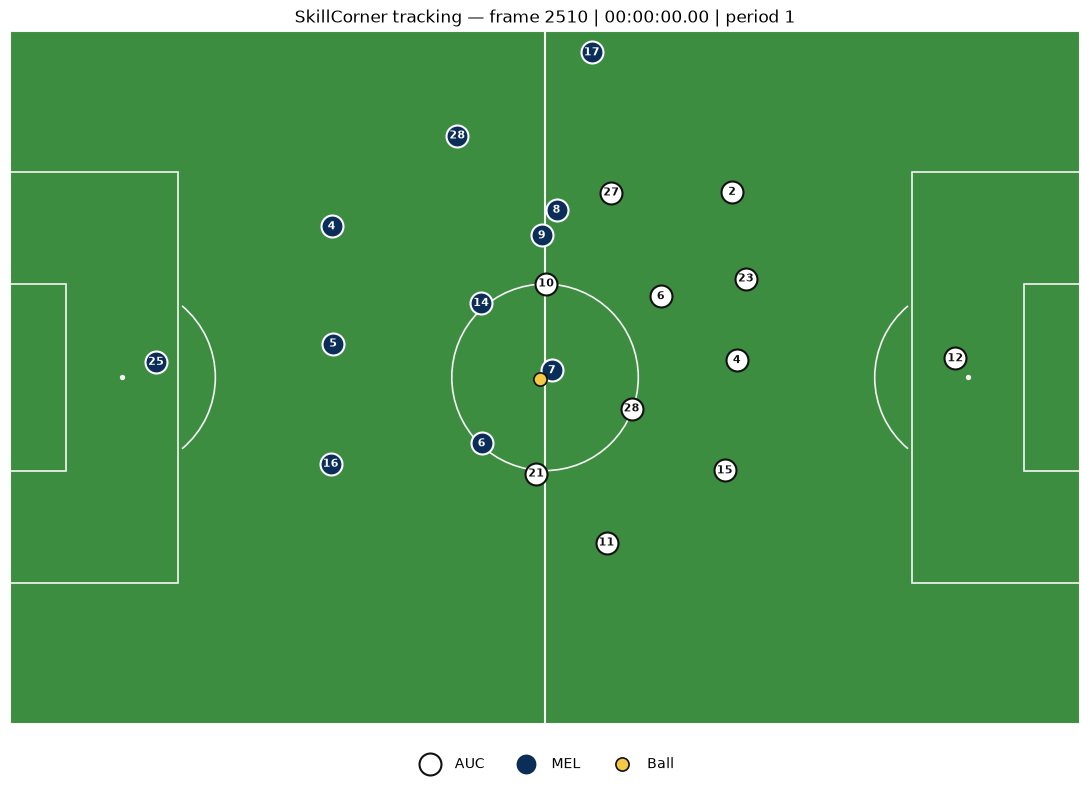

In [22]:
# Plot the first frame containing 11 tracked players from each team.
import matplotlib.pyplot as plt
from src.visualization import plot_tracking_frame

players_per_frame = tracking_players.groupby("frame")["player_id"].nunique()
first_complete_frame = int(players_per_frame[players_per_frame.eq(22)].index[0])

team_counts = (
    tracking_players.loc[tracking_players["frame"].eq(first_complete_frame)]
    .groupby("team_acronym")["player_id"]
    .nunique()
    .to_dict()
)
print(f"First complete 11v11 frame: {first_complete_frame}")
print(f"Players by team: {team_counts}")

ax = plot_tracking_frame(
    tracking_players, tracking_raw, match_info, frame=first_complete_frame
)
plt.show()

In [23]:
# Native-coordinate frame-level team shape metrics; no directional normalisation.
# Make the project source package importable even if this cell runs first.
import sys
from pathlib import Path

project_root = next(
    (candidate for candidate in [Path.cwd(), *Path.cwd().parents]
     if (candidate / "src" / "metrics").is_dir()),
    None,
)
if project_root is None:
    raise RuntimeError("Could not find the project src/metrics directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.metrics import calculate_team_shape

team_shape = calculate_team_shape(tracking_players)

print(f"Team-shape dataframe shape: {team_shape.shape}")
print(f"Index: {team_shape.index.names}")

display(
    team_shape.reset_index()
    .loc[lambda df: df["frame"].eq(2510)]
    .sort_values("team_acronym")
)

Team-shape dataframe shape: (80808, 9)
Index: ['frame', 'timestamp', 'elapsed_seconds', 'period', 'team_id', 'team_acronym']


,frame,timestamp,elapsed_seconds,period,team_id,team_acronym,full_team_width,full_team_length,full_team_centroid_x,full_team_centroid_y,outfield_width,outfield_length,outfield_centroid_x,outfield_centroid_y,player_count
1,2510,00:00:00.00,0.0,1,4177,AUC,34.41,41.13,13.318182,2.620909,34.41,20.58,10.623,2.697,11
0,2510,00:00:00.00,0.0,1,868,MEL,40.37,42.75,-10.533636,8.961818,40.37,25.62,-7.771,9.707,11


In [24]:
# Coverage audit only: this cell does not filter or modify any dataframe.
raw_player_count = tracking_raw["player_data"].apply(len)
raw_frame_ids = set(tracking_raw["frame"])
player_present_frame_ids = set(tracking_raw.loc[raw_player_count.gt(0), "frame"])
flattened_frame_ids = set(tracking_players["frame"])
shape_frame_ids = set(team_shape.index.get_level_values("frame"))

coverage_audit = pd.DataFrame([
    {"stage": "Raw tracking", "frame_count": len(raw_frame_ids),
     "excluded_from_previous": 0, "reason": "All source frames"},
    {"stage": "Frames with player data", "frame_count": len(player_present_frame_ids),
     "excluded_from_previous": len(raw_frame_ids - player_present_frame_ids),
     "reason": "Excluded only when player_data is empty"},
    {"stage": "Flattened player tracking", "frame_count": len(flattened_frame_ids),
     "excluded_from_previous": len(player_present_frame_ids - flattened_frame_ids),
     "reason": "No additional frame filtering"},
    {"stage": "Team Shape Engine", "frame_count": len(shape_frame_ids),
     "excluded_from_previous": len(flattened_frame_ids - shape_frame_ids),
     "reason": "No player-count filtering"},
])
display(coverage_audit)

period_audit = (
    tracking_raw.assign(has_player_data=raw_player_count.gt(0))
    .groupby("period", dropna=False)
    .agg(raw_frames=("frame", "size"), frames_with_player_data=("has_player_data", "sum"))
    .assign(excluded_empty_player_data=lambda df: df["raw_frames"] - df["frames_with_player_data"])
    .reset_index()
)
display(period_audit)

print("Raw player-record count per frame:")
display(raw_player_count.value_counts().sort_index().rename_axis("player_records").reset_index(name="frames"))

print("Player-count distribution per team-frame:")
display(team_shape["player_count"].value_counts().sort_index().rename_axis("player_count").reset_index(name="team_frames"))

print("Player-count distribution by team:")
display(team_shape.reset_index().groupby(["team_acronym", "player_count"]).size().reset_index(name="team_frames"))

print("The Team Shape Engine currently accepts partial team tracking; it does not require 11 players.")

,stage,frame_count,excluded_from_previous,reason
0,Raw tracking,71451,0,All source frames
1,Frames with player data,40404,31047,Excluded only when player_data is empty
2,Flattened player tracking,40404,0,No additional frame filtering
3,Team Shape Engine,40404,0,No player-count filtering


,period,raw_frames,frames_with_player_data,excluded_empty_player_data
0,1.0,27701,20777,6924
1,2.0,30751,19627,11124
2,NaN,12999,0,12999


Raw player-record count per frame:


,player_records,frames
0,0,31047
1,22,40404


Player-count distribution per team-frame:


,player_count,team_frames
0,11,80808


Player-count distribution by team:


,team_acronym,player_count,team_frames
0,AUC,11,40404
1,MEL,11,40404


The Team Shape Engine currently accepts partial team tracking; it does not require 11 players.


In [25]:
# Schema and interval audit only: phases are not merged into tracking data here.
phases_path = match_dir / f"{match_id}_phases_of_play.csv"
phases = pd.read_csv(phases_path)

print(f"Phase rows / columns: {phases.shape}")
print("\nAll columns:")
print(phases.columns.tolist())

print("\nRepresentative phase rows:")
display(phases.head(5))

print("\nFrame/time/team identifier fields:")
identifier_columns = [
    "match_id", "index", "frame_start", "frame_end", "time_start", "time_end",
    "period", "attacking_side_id", "attacking_side",
    "team_in_possession_id", "team_in_possession_shortname",
    "team_in_possession_phase_type", "team_out_of_possession_phase_type",
]
display(phases[identifier_columns].head(10))

print("\nUnique in-possession phase labels:")
print(sorted(phases["team_in_possession_phase_type"].dropna().unique()))
print("\nUnique out-of-possession phase labels:")
print(sorted(phases["team_out_of_possession_phase_type"].dropna().unique()))

in_phase_summary = (
    phases.groupby(["team_in_possession_id", "team_in_possession_shortname", "team_in_possession_phase_type"])
    .agg(interval_count=("index", "size"), total_duration_seconds=("duration", "sum"))
    .reset_index()
    .sort_values(["team_in_possession_shortname", "team_in_possession_phase_type"])
)
out_phase_summary = (
    phases.groupby(["team_in_possession_id", "team_in_possession_shortname", "team_out_of_possession_phase_type"])
    .agg(interval_count=("index", "size"), total_duration_seconds=("duration", "sum"))
    .reset_index()
    .sort_values(["team_in_possession_shortname", "team_out_of_possession_phase_type"])
)
print("\nIn-possession phase counts and durations:")
display(in_phase_summary)
print("\nOut-of-possession phase counts and durations (labelled against the opponent of the in-possession team):")
display(out_phase_summary)

# Interval alignment: duration equals (frame_end - frame_start) / 10, so end frames are exclusive.
phase_intervals = phases.sort_values(["period", "frame_start"]).copy()
phase_intervals["frame_span"] = phase_intervals["frame_end"] - phase_intervals["frame_start"]
phase_intervals["duration_from_frames"] = phase_intervals["frame_span"] / 10
phase_intervals["duration_matches_frames"] = (
    phase_intervals["duration"] - phase_intervals["duration_from_frames"]
).abs().lt(1e-9)
phase_intervals["next_frame_start"] = phase_intervals.groupby("period")["frame_start"].shift(-1)
phase_intervals["gap_to_next_frame"] = phase_intervals["next_frame_start"] - phase_intervals["frame_end"]

print("\nInterval alignment audit:")
print(f"All durations match (frame_end - frame_start) / 10: {phase_intervals['duration_matches_frames'].all()}")
print(f"Phase start frames present in raw tracking: {phases['frame_start'].isin(tracking_raw['frame']).all()}")
print(f"Phase end frames present in raw tracking: {phases['frame_end'].isin(tracking_raw['frame']).all()}")
print(phase_intervals["gap_to_next_frame"].dropna().value_counts().sort_index().rename_axis("gap_frames").reset_index(name="transitions"))

print("\nSafest future join rule (not run here): match on match_id, then use frame_start <= tracking_frame < frame_end; retain period as a validation guard.")
print("Each interval explicitly stores the in-possession team and both in- and out-of-possession phase labels. The defending team ID must be inferred as the other match team; it is not a separate phase-file column.")

Phase rows / columns: (437, 44)

All columns:
['index', 'match_id', 'frame_start', 'frame_end', 'time_start', 'time_end', 'minute_start', 'second_start', 'duration', 'period', 'attacking_side_id', 'team_in_possession_id', 'attacking_side', 'team_in_possession_shortname', 'n_player_possessions_in_phase', 'team_possession_loss_in_phase', 'team_possession_lead_to_goal', 'team_possession_lead_to_shot', 'team_in_possession_phase_type', 'team_in_possession_phase_type_id', 'team_out_of_possession_phase_type', 'team_out_of_possession_phase_type_id', 'x_start', 'y_start', 'channel_id_start', 'channel_start', 'third_id_start', 'third_start', 'penalty_area_start', 'x_end', 'y_end', 'channel_id_end', 'channel_end', 'third_id_end', 'third_end', 'penalty_area_end', 'team_in_possession_width_start', 'team_in_possession_width_end', 'team_in_possession_length_start', 'team_in_possession_length_end', 'team_out_of_possession_width_start', 'team_out_of_possession_width_end', 'team_out_of_possession_length

,index,match_id,frame_start,frame_end,time_start,time_end,minute_start,second_start,duration,period,...,third_end,penalty_area_end,team_in_possession_width_start,team_in_possession_width_end,team_in_possession_length_start,team_in_possession_length_end,team_out_of_possession_width_start,team_out_of_possession_width_end,team_out_of_possession_length_start,team_out_of_possession_length_end
0,0,2017461,2512,2540,00:00.2,00:03.0,0,0,2.8,1,...,defensive_third,False,40.94,42.11,43.49,53.80,34.80,31.53,41.92,54.89
1,1,2017461,2540,2573,00:03.0,00:06.3,0,3,3.3,1,...,attacking_third,False,42.04,35.13,54.19,64.79,31.55,27.82,55.14,57.02
2,2,2017461,2573,2591,00:06.3,00:08.1,0,6,1.8,1,...,middle_third,False,27.69,23.51,56.97,54.32,34.82,32.71,64.84,63.16
3,3,2017461,2591,2672,00:08.1,00:16.2,0,8,8.1,1,...,attacking_third,True,32.68,29.56,63.32,80.36,23.56,22.04,54.03,26.11
4,4,2017461,2845,2901,00:33.5,00:39.1,0,33,5.6,1,...,middle_third,False,NaN,36.53,NaN,44.17,NaN,41.80,NaN,66.08



Frame/time/team identifier fields:


,match_id,index,frame_start,frame_end,time_start,time_end,period,attacking_side_id,attacking_side,team_in_possession_id,team_in_possession_shortname,team_in_possession_phase_type,team_out_of_possession_phase_type
0,2017461,0,2512,2540,00:00.2,00:03.0,1,1,left_to_right,868,Melbourne V FC,create,medium_block
1,2017461,1,2540,2573,00:03.0,00:06.3,1,1,left_to_right,868,Melbourne V FC,direct,defending_direct
2,2017461,2,2573,2591,00:06.3,00:08.1,1,2,right_to_left,4177,Auckland FC,chaotic,chaotic
3,2017461,3,2591,2672,00:08.1,00:16.2,1,1,left_to_right,868,Melbourne V FC,finish,low_block
4,2017461,4,2845,2901,00:33.5,00:39.1,1,1,left_to_right,868,Melbourne V FC,set_play,defending_set_play
5,2017461,5,2901,2934,00:39.1,00:42.4,1,2,right_to_left,4177,Auckland FC,transition,defending_transition
6,2017461,6,2934,2983,00:42.4,00:47.3,1,1,left_to_right,868,Melbourne V FC,chaotic,chaotic
7,2017461,7,2983,3014,00:47.3,00:50.4,1,1,left_to_right,868,Melbourne V FC,direct,defending_direct
8,2017461,8,3014,3067,00:50.4,00:55.7,1,2,right_to_left,4177,Auckland FC,chaotic,chaotic
9,2017461,9,3067,3139,00:55.7,01:02.9,1,1,left_to_right,868,Melbourne V FC,create,medium_block



Unique in-possession phase labels:
['build_up', 'chaotic', 'create', 'direct', 'finish', 'quick_break', 'set_play', 'transition']

Unique out-of-possession phase labels:
['chaotic', 'defending_direct', 'defending_quick_break', 'defending_set_play', 'defending_transition', 'high_block', 'low_block', 'medium_block']

In-possession phase counts and durations:


,team_in_possession_id,team_in_possession_shortname,team_in_possession_phase_type,interval_count,total_duration_seconds
8,4177,Auckland FC,build_up,9,59.4
9,4177,Auckland FC,chaotic,85,296.7
10,4177,Auckland FC,create,45,369.3
11,4177,Auckland FC,direct,15,46.5
12,4177,Auckland FC,finish,25,154.0
13,4177,Auckland FC,quick_break,2,21.6
14,4177,Auckland FC,set_play,8,38.7
15,4177,Auckland FC,transition,11,115.1
0,868,Melbourne V FC,build_up,21,165.4
1,868,Melbourne V FC,chaotic,58,186.1



Out-of-possession phase counts and durations (labelled against the opponent of the in-possession team):


,team_in_possession_id,team_in_possession_shortname,team_out_of_possession_phase_type,interval_count,total_duration_seconds
8,4177,Auckland FC,chaotic,85,296.7
9,4177,Auckland FC,defending_direct,15,46.5
10,4177,Auckland FC,defending_quick_break,2,21.6
11,4177,Auckland FC,defending_set_play,8,38.7
12,4177,Auckland FC,defending_transition,11,115.1
13,4177,Auckland FC,high_block,9,59.4
14,4177,Auckland FC,low_block,25,154.0
15,4177,Auckland FC,medium_block,45,369.3
0,868,Melbourne V FC,chaotic,58,186.1
1,868,Melbourne V FC,defending_direct,29,89.8



Interval alignment audit:
All durations match (frame_end - frame_start) / 10: True
Phase start frames present in raw tracking: True
Phase end frames present in raw tracking: True
    gap_frames  transitions
0          0.0          331
1         23.0            1
2         34.0            1
3         41.0            1
4         43.0            1
..         ...          ...
93       752.0            1
94       845.0            1
95      1206.0            1
96      1226.0            1
97      1539.0            1

[98 rows x 2 columns]

Safest future join rule (not run here): match on match_id, then use frame_start <= tracking_frame < frame_end; retain period as a validation guard.
Each interval explicitly stores the in-possession team and both in- and out-of-possession phase labels. The defending team ID must be inferred as the other match team; it is not a separate phase-file column.


In [26]:
# Expand only defined phase intervals, then left-join them to Team Shape.
# Shape rows outside a phase interval remain unlabelled.
import sys

project_root = match_dir.parents[3]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data import (
    audit_phase_context_join,
    expand_phase_context,
    join_phase_context_to_team_shape,
)

phase_context = expand_phase_context(phases, match_info)
team_shape_with_context = join_phase_context_to_team_shape(
    team_shape, phase_context, match_info
)
phase_context_coverage = audit_phase_context_join(
    team_shape, phase_context, match_info
)

print("Phase-context coverage and validation:")
display(pd.Series(phase_context_coverage, name="value").to_frame())

print("\nFirst expanded team-frame context rows:")
display(phase_context.head(6))

print("\nJoined Team Shape context at frame 2512:")
display(
    team_shape_with_context.reset_index()
    .loc[lambda df: df["frame"].eq(2512)]
    .sort_values("team_acronym")
    [["frame", "period", "team_id", "team_acronym", "possession_status",
      "tactical_phase", "phase_frame_start", "phase_frame_end"]]
)

print("\nExample unlabelled Team Shape rows (phase gaps are not forward-filled):")
display(
    team_shape_with_context.reset_index()
    .loc[lambda df: df["tactical_phase"].isna()]
    [["frame", "period", "team_acronym", "tactical_phase"]]
    .head(6)
)

Phase-context coverage and validation:


,value
context_team_frame_rows,56490
duplicate_context_team_frames,0
interval_boundaries_valid,True
unmatched_phase_team_frames,1648
unmatched_shape_team_frames,25966



First expanded team-frame context rows:


,match_id,frame,period,team_id,possession_status,tactical_phase,possession_team_id,phase_frame_start,phase_frame_end,phase_duration,team_possession_lead_to_shot,team_possession_lead_to_goal
0,2017461,2512,1,868,in_possession,create,868,2512,2540,2.8,False,False
1,2017461,2512,1,4177,out_of_possession,medium_block,868,2512,2540,2.8,False,False
2,2017461,2513,1,868,in_possession,create,868,2512,2540,2.8,False,False
3,2017461,2513,1,4177,out_of_possession,medium_block,868,2512,2540,2.8,False,False
4,2017461,2514,1,868,in_possession,create,868,2512,2540,2.8,False,False
5,2017461,2514,1,4177,out_of_possession,medium_block,868,2512,2540,2.8,False,False



Joined Team Shape context at frame 2512:


,frame,period,team_id,team_acronym,possession_status,tactical_phase,phase_frame_start,phase_frame_end
5,2512,1,4177,AUC,out_of_possession,medium_block,2512.0,2540.0
4,2512,1,868,MEL,in_possession,create,2512.0,2540.0



Example unlabelled Team Shape rows (phase gaps are not forward-filled):


,frame,period,team_acronym,tactical_phase
0,2510,1,MEL,NaN
1,2510,1,AUC,NaN
2,2511,1,MEL,NaN
3,2511,1,AUC,NaN
324,2672,1,MEL,NaN
325,2672,1,AUC,NaN


In [27]:
# Descriptive phase-shape summary only; no recommendation or causal interpretation.
import sys

project_root = match_dir.parents[3]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.analysis import summarize_phase_shape

phase_shape_summary = summarize_phase_shape(team_shape_with_context)
requested_phases = [
    "build_up", "create", "finish", "high_block", "medium_block", "low_block",
]
melbourne_phase_shape = (
    phase_shape_summary
    .loc[lambda df: df["team_acronym"].eq("MEL") & df["tactical_phase"].isin(requested_phases)]
    .sort_values(["possession_status", "tactical_phase"])
)

print("Melbourne Victory phase-shape summary (native SkillCorner coordinates):")
display(melbourne_phase_shape)
print("phase_interval_count is the number of distinct source intervals with at least one matched Team Shape frame.")

Melbourne Victory phase-shape summary (native SkillCorner coordinates):


,team_id,team_acronym,possession_status,tactical_phase,frame_count,represented_seconds,phase_interval_count,median_outfield_width,q25_outfield_width,q75_outfield_width,median_outfield_length,q25_outfield_length,q75_outfield_length
0,868,MEL,in_possession,build_up,1573,157.3,21,43.670,34.0500,54.2700,37.570,33.5900,40.64
2,868,MEL,in_possession,create,5890,589.0,70,50.095,44.3025,54.7075,33.730,30.8725,36.34
4,868,MEL,in_possession,finish,4870,487.0,39,40.210,34.8200,46.1675,32.430,29.0825,35.90
13,868,MEL,out_of_possession,high_block,594,59.4,9,32.405,28.4400,37.4375,34.545,32.4550,36.79
14,868,MEL,out_of_possession,low_block,1540,154.0,25,33.035,28.7425,39.2800,29.355,22.7375,34.90
15,868,MEL,out_of_possession,medium_block,3477,347.7,44,35.480,31.8100,38.6400,25.230,21.9300,29.51


phase_interval_count is the number of distinct source intervals with at least one matched Team Shape frame.


### Melbourne Victory phase-shape output snapshot

This is the current result for match `2017461`, calculated from matched Team Shape and phase-context rows. Run the preceding phase-context and summary cells to regenerate it.

| Possession status | Tactical phase | Frame count | Represented seconds | Distinct matched intervals | Median outfield width | Q25 width | Q75 width | Median outfield length | Q25 length | Q75 length |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| In possession | build_up | 1,573 | 157.3 | 21 | 43.670 | 34.0500 | 54.2700 | 37.570 | 33.5900 | 40.640 |
| In possession | create | 5,890 | 589.0 | 70 | 50.095 | 44.3025 | 54.7075 | 33.730 | 30.8725 | 36.340 |
| In possession | finish | 4,870 | 487.0 | 39 | 40.210 | 34.8200 | 46.1675 | 32.430 | 29.0825 | 35.900 |
| Out of possession | high_block | 594 | 59.4 | 9 | 32.405 | 28.4400 | 37.4375 | 34.545 | 32.4550 | 36.790 |
| Out of possession | medium_block | 3,477 | 347.7 | 44 | 35.480 | 31.8100 | 38.6400 | 25.230 | 21.9300 | 29.510 |
| Out of possession | low_block | 1,540 | 154.0 | 25 | 33.035 | 28.7425 | 39.2800 | 29.355 | 22.7375 | 34.900 |

`phase_interval_count` counts only source intervals that have at least one matched Team Shape frame.